# LATIHAN
## Python + Google Colab + BigQuery — Data Cleaning & EDA TheLook Ecommerce

**Dataset:** `bigquery-public-data.thelook_ecommerce`  
**Level:** Basic / Pemula

### Alur Project
**BigQuery → Pandas → Cleaning → EDA → Insight**

Dataset tetap menggunakan TheLook Ecommerce agar project berkesinambungan dari sesi sebelumnya.

> Pada sesi ini fokusnya adalah **data cleaning dan exploratory data analysis (EDA) sederhana**. Tidak menggunakan JOIN kompleks.


## 1. Setup Google Colab & BigQuery

In [ ]:
!pip -q install google-cloud-bigquery db-dtypes


In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "my-project-2602-505412"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)


Connected to: my-project-2602-505412


## 2. Cek Dataset TheLook Ecommerce

In [ ]:
query = '''
SELECT
  table_name
FROM `bigquery-public-data.thelook_ecommerce.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
'''

client.query(query).to_dataframe()


,table_name
0,distribution_centers
1,events
2,inventory_items
3,order_items
4,orders
5,products
6,users


# BAGIAN A — AMBIL DATA DARI BIGQUERY

## 3. Ambil Data Orders

Kita gunakan tabel `orders` sebagai dataset utama.


In [ ]:
query = '''
SELECT
  order_id,
  user_id,
  status,
  created_at
FROM `bigquery-public-data.thelook_ecommerce.orders`
'''

df = client.query(query).to_dataframe()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 124775
Columns: 4


## 4. Melihat Data Awal

In [ ]:
df.head()


,order_id,user_id,status,created_at
0,1,1,Cancelled,2025-04-13 21:06:41+00:00
1,6,4,Cancelled,2020-09-29 10:51:01+00:00
2,8,5,Cancelled,2023-10-10 01:26:21+00:00
3,30,24,Cancelled,2026-02-09 03:36:36+00:00
4,40,30,Cancelled,2025-05-18 14:23:33+00:00


# BAGIAN B — DATA UNDERSTANDING

## 5. Cek Struktur Data

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124775 entries, 0 to 124774
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype              
---  ------      --------------   -----              
 0   order_id    124775 non-null  Int64              
 1   user_id     124775 non-null  Int64              
 2   status      124775 non-null  object             
 3   created_at  124775 non-null  datetime64[us, UTC]
dtypes: Int64(2), datetime64[us, UTC](1), object(1)
memory usage: 4.0+ MB


## 6. Cek Jumlah Baris dan Kolom

In [ ]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])


Jumlah baris : 124775
Jumlah kolom : 4


## 7. Cek Missing Value

Hitung nilai kosong setiap kolom.


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing


,0
order_id,0
user_id,0
status,0
created_at,0


## 8. Cek Duplicate

In [ ]:
duplicate_count = df.duplicated().sum()

print("Jumlah duplicate:", duplicate_count)


Jumlah duplicate: 0


# BAGIAN C — DATA CLEANING

## 9. Menghapus Duplicate

Untuk dataset latihan, duplicate dapat dihapus jika memang bukan record transaksi yang berbeda.


In [ ]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Sebelum :", before)
print("Sesudah :", after)
print("Dihapus :", before - after)


Sebelum : 124775
Sesudah : 124775
Dihapus : 0


## 10. Cleaning Kolom Tanggal

Pastikan `created_at` bertipe datetime.


In [ ]:
import pandas as pd

df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce"
)

print(df["created_at"].dtype)


datetime64[us, UTC]


## 11. Cek Missing Setelah Konversi Tanggal

In [ ]:
df["created_at"].isna().sum()


np.int64(0)

## 12. Membuat Kolom Tanggal

Kolom `order_date` akan berguna untuk analisis harian.


In [ ]:
df["order_date"] = df["created_at"].dt.date

df[["created_at", "order_date"]].head()


,created_at,order_date
0,2025-04-13 21:06:41+00:00,2025-04-13
1,2020-09-29 10:51:01+00:00,2020-09-29
2,2023-10-10 01:26:21+00:00,2023-10-10
3,2026-02-09 03:36:36+00:00,2026-02-09
4,2025-05-18 14:23:33+00:00,2025-05-18


## 13. Validasi Status

Lihat kategori status yang tersedia.


In [ ]:
df["status"].value_counts(dropna=False)


,count
status,
Shipped,37493
Complete,31222
Processing,24903
Cancelled,18733
Returned,12424


# BAGIAN D — EDA DASAR

## 14. Total Orders

In [ ]:
total_orders = len(df)

print("Total Orders:", total_orders)


Total Orders: 124775


## 15. Orders per Status

In [ ]:
status_summary = (
    df["status"]
      .value_counts()
      .reset_index()
)

status_summary.columns = [
    "status",
    "total_orders"
]

status_summary


,status,total_orders
0,Shipped,37493
1,Complete,31222
2,Processing,24903
3,Cancelled,18733
4,Returned,12424


## 16. Complete Orders

In [ ]:
complete_orders = (df["status"] == "Complete").sum()

print("Complete Orders:", complete_orders)


Complete Orders: 31222


## 17. Complete Rate

In [ ]:
complete_rate = round(
    complete_orders / total_orders * 100,
    2
)

print("Complete Rate:", complete_rate, "%")


Complete Rate: 25.02 %


## 18. Orders per Date

In [ ]:
daily_orders = (
    df.groupby("order_date")
      .size()
      .reset_index(name="total_orders")
      .sort_values("total_orders", ascending=False)
)

daily_orders.head(10)


,order_date,total_orders
2725,2026-08-27,1791
2724,2026-08-26,1106
2723,2026-08-25,802
2722,2026-08-24,547
2721,2026-08-23,430
2720,2026-08-22,334
2719,2026-08-21,280
2718,2026-08-20,272
2714,2026-08-16,271
2717,2026-08-19,250


## 19. Orders per Month

In [ ]:
df["month"] = (
    df["created_at"]
      .dt.to_period("M")
      .astype(str)
)

monthly_orders = (
    df.groupby("month")
      .size()
      .reset_index(name="total_orders")
)

monthly_orders.head(10)


/tmp/ipykernel_778/1895575624.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,month,total_orders
0,2019-01,7
1,2019-02,17
2,2019-03,24
3,2019-04,65
4,2019-05,68
5,2019-06,77
6,2019-07,108
7,2019-08,105
8,2019-09,121
9,2019-10,147


## 20. Visualisasi Monthly Orders

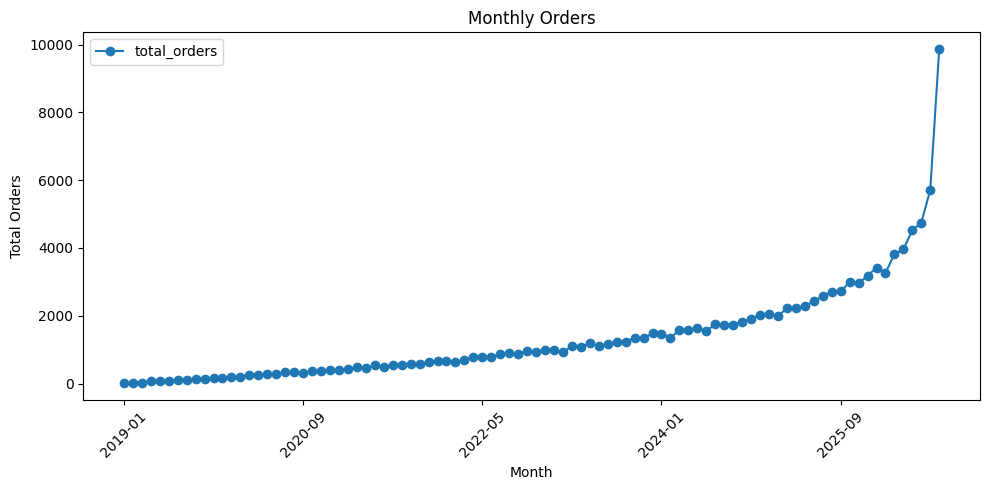

In [ ]:
import matplotlib.pyplot as plt

monthly_orders.plot(
    x="month",
    y="total_orders",
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 21. Visualisasi Status

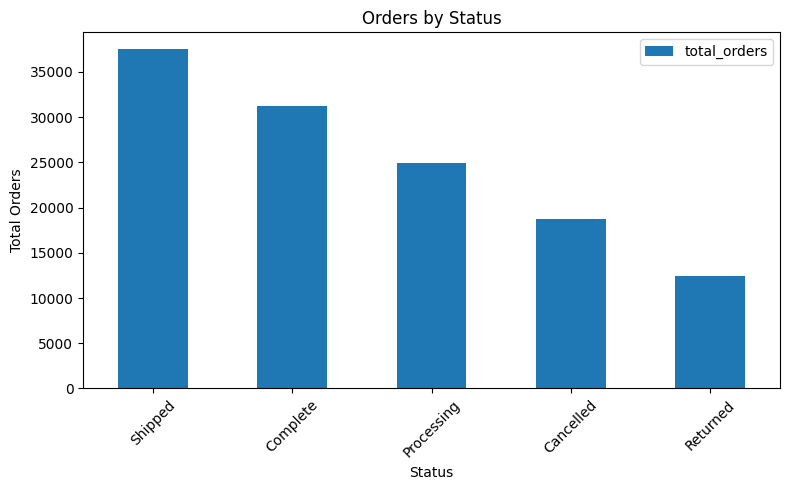

In [ ]:
status_summary.plot(
    x="status",
    y="total_orders",
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# BAGIAN E — BUSINESS QUESTIONS

## 22. Pertanyaan Analisis

Gunakan hasil EDA untuk menjawab:

1. Berapa total order?
2. Status apa yang paling banyak?
3. Berapa Complete Orders?
4. Berapa Complete Rate?
5. Bulan mana yang memiliki order terbanyak?
6. Hari mana yang memiliki order terbanyak?


In [ ]:
print("===== KEY METRICS =====")
print("Total Orders   :", total_orders)
print("Complete Orders:", complete_orders)
print("Complete Rate  :", complete_rate, "%")
print()

print("Status Summary:")
display(status_summary)

print("Top 10 Dates:")
display(daily_orders.head(10))

print("Monthly Orders:")
display(monthly_orders)


===== KEY METRICS =====
Total Orders   : 124775
Complete Orders: 31222
Complete Rate  : 25.02 %

Status Summary:


,status,total_orders
0,Shipped,37493
1,Complete,31222
2,Processing,24903
3,Cancelled,18733
4,Returned,12424


Top 10 Dates:


,order_date,total_orders
2725,2026-08-27,1791
2724,2026-08-26,1106
2723,2026-08-25,802
2722,2026-08-24,547
2721,2026-08-23,430
2720,2026-08-22,334
2719,2026-08-21,280
2718,2026-08-20,272
2714,2026-08-16,271
2717,2026-08-19,250


Monthly Orders:


,month,total_orders
0,2019-01,7
1,2019-02,17
2,2019-03,24
3,2019-04,65
4,2019-05,68
...,...,...
87,2026-04,3956
88,2026-05,4524
89,2026-06,4746
90,2026-07,5714


# BAGIAN F — HANDS-ON CLEANING CHECK

## 23. Final Data Quality Check

In [ ]:
print("===== FINAL DATA QUALITY CHECK =====")
print("Rows            :", len(df))
print("Columns         :", len(df.columns))
print("Missing values  :", int(df.isna().sum().sum()))
print("Duplicate rows  :", int(df.duplicated().sum()))
print("Invalid dates   :", int(df["created_at"].isna().sum()))


===== FINAL DATA QUALITY CHECK =====
Rows            : 124775
Columns         : 6
Missing values  : 0
Duplicate rows  : 0
Invalid dates   : 0


## 24. Simpan Dataset Bersih

Dataset ini akan menjadi input untuk sesi berikutnya.


In [ ]:
clean_file = "thelook_clean_session7.csv"

df.to_csv(
    clean_file,
    index=False
)

print("File berhasil dibuat:", clean_file)


File berhasil dibuat: thelook_clean_session7.csv


In [ ]:
from google.colab import files

files.download("thelook_clean_session7.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# MINI PROJECT SESI 7

### Business Question
**“Bagaimana kondisi order TheLook Ecommerce setelah data dibersihkan?”**

Peserta harus menghasilkan:
- Clean dataset
- Total Orders
- Status Summary
- Complete Orders
- Complete Rate
- Daily Orders
- Monthly Orders
- Minimal 2 insight dari hasil EDA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.cloud import bigquery

from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "my-project-2602-505412"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)


Connected to: my-project-2602-505412


In [ ]:
query = '''
SELECT
  table_name
FROM `bigquery-public-data.thelook_ecommerce.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
'''

client.query(query).to_dataframe()

,table_name
0,distribution_centers
1,events
2,inventory_items
3,order_items
4,orders
5,products
6,users


In [ ]:
query = """
SELECT
    order_id,
    user_id,
    status,
    created_at,
    returned_at,
    shipped_at,
    delivered_at,
    num_of_item
FROM `bigquery-public-data.thelook_ecommerce.orders`
"""

orders = client.query(query).to_dataframe()

print("Dataset berhasil di-load.")
print("Jumlah rows:", len(orders))
print("Jumlah columns:", len(orders.columns))

orders.head()


Dataset berhasil di-load.
Jumlah rows: 124775
Jumlah columns: 8


,order_id,user_id,status,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,1,1,Cancelled,2025-04-13 21:06:41+00:00,NaT,NaT,NaT,2
1,6,4,Cancelled,2020-09-29 10:51:01+00:00,NaT,NaT,NaT,1
2,8,5,Cancelled,2023-10-10 01:26:21+00:00,NaT,NaT,NaT,2
3,30,24,Cancelled,2026-02-09 03:36:36+00:00,NaT,NaT,NaT,1
4,40,30,Cancelled,2025-05-18 14:23:33+00:00,NaT,NaT,NaT,2


In [ ]:
#Data understanding (cek missing value, duplicate, etc)

print("Shape dataset:")
print(orders.shape)

print("\nData types:")
print(orders.dtypes)

print("\nMissing values:")
print(orders.isnull().sum())

print("\nDuplicate rows:")
print(orders.duplicated().sum())

print("\nUnique order IDs:")
print(orders["order_id"].nunique())

print("\nOrder status:")
print(orders["status"].value_counts())


Shape dataset:
(124775, 8)

Data types:
order_id                      Int64
user_id                       Int64
status                       object
created_at      datetime64[us, UTC]
returned_at     datetime64[us, UTC]
shipped_at      datetime64[us, UTC]
delivered_at    datetime64[us, UTC]
num_of_item                   Int64
dtype: object

Missing values:
order_id             0
user_id              0
status               0
created_at           0
returned_at     112351
shipped_at       43636
delivered_at     81129
num_of_item          0
dtype: int64

Duplicate rows:
0

Unique order IDs:
124775

Order status:
status
Shipped       37493
Complete      31222
Processing    24903
Cancelled     18733
Returned      12424
Name: count, dtype: int64


In [ ]:
# Summary dataset

summary = pd.DataFrame({
    "Column": orders.columns,
    "Data Type": orders.dtypes.values,
    "Missing Values": orders.isnull().sum().values,
    "Unique Values": orders.nunique().values
})

summary


,Column,Data Type,Missing Values,Unique Values
0,order_id,Int64,0,124775
1,user_id,Int64,0,79948
2,status,object,0,5
3,created_at,"datetime64[us, UTC]",0,124715
4,returned_at,"datetime64[us, UTC]",112351,12424
5,shipped_at,"datetime64[us, UTC]",43636,81114
6,delivered_at,"datetime64[us, UTC]",81129,43641
7,num_of_item,Int64,0,4


In [ ]:
# Data Cleaning

# Copy dataset
clean_orders = orders.copy()

# Convert created_at to datetime
clean_orders["created_at"] = pd.to_datetime(
    clean_orders["created_at"],
    errors="coerce"
)

# Convert other date columns
date_columns = [
    "returned_at",
    "shipped_at",
    "delivered_at"
]

for col in date_columns:
    clean_orders[col] = pd.to_datetime(
        clean_orders[col],
        errors="coerce"
    )

# Standardize status
clean_orders["status"] = (
    clean_orders["status"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Remove rows without order_id
clean_orders = clean_orders.dropna(
    subset=["order_id"]
)

# Remove duplicate order_id
clean_orders = clean_orders.drop_duplicates(
    subset=["order_id"]
)

# Remove rows where created_at cannot be identified
clean_orders = clean_orders.dropna(
    subset=["created_at"]
)

# Sort by created_at
clean_orders = clean_orders.sort_values(
    "created_at"
).reset_index(drop=True)

print("Cleaning selesai.")
print("Rows setelah cleaning:", len(clean_orders))
print("Columns:", len(clean_orders.columns))

clean_orders.head()


Cleaning selesai.
Rows setelah cleaning: 124775
Columns: 8


,order_id,user_id,status,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,97710,78305,Shipped,2019-01-12 12:22:41+00:00,NaT,2019-01-13 02:59:41+00:00,NaT,1
1,38529,31023,Processing,2019-01-22 07:17:28+00:00,NaT,NaT,NaT,2
2,15684,12606,Shipped,2019-01-24 18:54:12+00:00,NaT,2019-01-26 23:30:12+00:00,NaT,1
3,115952,92919,Complete,2019-01-27 02:39:05+00:00,NaT,2019-01-28 17:40:05+00:00,2019-02-01 15:49:05+00:00,1
4,83267,66736,Processing,2019-01-29 22:48:12+00:00,NaT,NaT,NaT,1


In [ ]:
# Validation after cleaning

print("Duplicate order_id:",
      clean_orders["order_id"].duplicated().sum())

print("Missing order_id:",
      clean_orders["order_id"].isna().sum())

print("Missing created_at:",
      clean_orders["created_at"].isna().sum())

print("\nStatus setelah cleaning:")
print(clean_orders["status"].value_counts())

print("\nFinal shape:")
print(clean_orders.shape)


Duplicate order_id: 0
Missing order_id: 0
Missing created_at: 0

Status setelah cleaning:
status
Shipped       37493
Complete      31222
Processing    24903
Cancelled     18733
Returned      12424
Name: count, dtype: int64

Final shape:
(124775, 8)


In [ ]:
# Total orders

total_orders = clean_orders["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")


Total Orders: 124,775


In [ ]:
# Cek Status Summary

status_summary = (
    clean_orders
    .groupby("status")
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

# Add percentage
status_summary["percentage"] = (
    status_summary["total_orders"] /
    total_orders * 100
)

status_summary["percentage"] = (
    status_summary["percentage"].round(2)
)

status_summary = status_summary.sort_values(
    "total_orders",
    ascending=False
)

status_summary


,status,total_orders,percentage
4,Shipped,37493,30.05
1,Complete,31222,25.02
2,Processing,24903,19.96
0,Cancelled,18733,15.01
3,Returned,12424,9.96


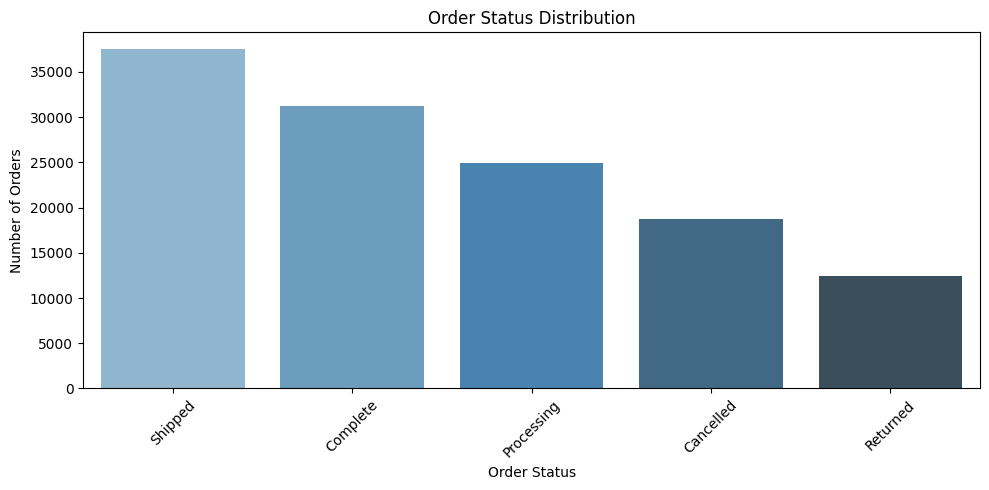

In [ ]:
# Visualisasi Data Distribusi

plt.figure(figsize=(10, 5))

sns.barplot(
    data=status_summary,
    x="status",
    y="total_orders",
    hue="status",
    palette="Blues_d",
    legend=False
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Completed Orders

complete_orders = clean_orders[
    clean_orders["status"] == "Complete"
]["order_id"].nunique()

print(f"Complete Orders: {complete_orders:,}")


Complete Orders: 31,222


In [ ]:
# Completed Rate

complete_rate = (
    complete_orders / total_orders * 100
)

print(f"Complete Rate: {complete_rate:.2f}%")


Complete Rate: 25.02%


In [ ]:
# Daily orders

clean_orders["order_date"] = (
    clean_orders["created_at"]
    .dt.date
)

daily_orders = (
    clean_orders
    .groupby("order_date")
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

daily_orders["order_date"] = pd.to_datetime(
    daily_orders["order_date"]
)

daily_orders.head()



,order_date,total_orders
0,2019-01-12,1
1,2019-01-22,1
2,2019-01-24,1
3,2019-01-27,1
4,2019-01-29,1


In [ ]:
# Monthly Orders

clean_orders["order_month"] = (
    clean_orders["created_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_orders = (
    clean_orders
    .groupby("order_month")
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_orders.head()


/tmp/ipykernel_4200/424487075.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,order_month,total_orders
0,2019-01,7
1,2019-02,17
2,2019-03,24
3,2019-04,65
4,2019-05,68


In [ ]:
# INSIGHT
# Status dengan jumlah terbesar
top_status = status_summary.iloc[0]

# Highest monthly order
highest_month = monthly_orders.loc[
    monthly_orders["total_orders"].idxmax()
]

# Lowest monthly order
lowest_month = monthly_orders.loc[
    monthly_orders["total_orders"].idxmin()
]

# Peak daily order
peak_day = daily_orders.loc[
    daily_orders["total_orders"].idxmax()
]

print("=== BUSINESS INSIGHTS ===\n")

print(
    f"1. Status order terbesar adalah '{top_status['status']}' "
    f"dengan {top_status['total_orders']:,} orders "
    f"({top_status['percentage']:.2f}% dari total orders)."
)

print(
    f"2. Complete Rate TheLook Ecommerce adalah "
    f"{complete_rate:.2f}%, dengan "
    f"{complete_orders:,} complete orders dari "
    f"{total_orders:,} total orders."
)

print(
    f"3. Bulan dengan jumlah order tertinggi adalah "
    f"{highest_month['order_month']} dengan "
    f"{highest_month['total_orders']:,} orders."
)

print(
    f"4. Hari dengan jumlah order tertinggi adalah "
    f"{peak_day['order_date'].date()} dengan "
    f"{peak_day['total_orders']:,} orders."
)

print(
    f"5. Bulan dengan jumlah order terendah adalah "
    f"{lowest_month['order_month']} dengan "
    f"{lowest_month['total_orders']:,} orders."
)


=== BUSINESS INSIGHTS ===

1. Status order terbesar adalah 'Shipped' dengan 37,493 orders (30.05% dari total orders).
2. Complete Rate TheLook Ecommerce adalah 25.02%, dengan 31,222 complete orders dari 124,775 total orders.
3. Bulan dengan jumlah order tertinggi adalah 2026-08 dengan 9,867 orders.
4. Hari dengan jumlah order tertinggi adalah 2026-08-27 dengan 1,791 orders.
5. Bulan dengan jumlah order terendah adalah 2019-01 dengan 7 orders.


# LATIHAN MANDIRI

### Soal 1
Cari 10 tanggal dengan jumlah order terbanyak.

### Soal 2
Cari bulan dengan jumlah order terbanyak.

### Soal 3
Hitung persentase masing-masing status.

### Soal 4
Buat satu visualisasi tambahan.

### Soal 5
Tuliskan minimal 2 insight berdasarkan data.

**Hint:** gunakan `groupby()`, `value_counts()`, `sort_values()`, dan filtering.


In [ ]:
# 10 Tanggal dengan order ternayak

top_10_dates = (
    clean_orders
    .groupby(clean_orders["created_at"].dt.date)["order_id"]
    .nunique()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False)
    .head(10)
)

top_10_dates


,created_at,total_orders
2725,2026-08-27,1791
2724,2026-08-26,1106
2723,2026-08-25,802
2722,2026-08-24,547
2721,2026-08-23,430
2720,2026-08-22,334
2719,2026-08-21,280
2718,2026-08-20,272
2714,2026-08-16,271
2717,2026-08-19,250


In [ ]:
# Bulan dengan order terbanyak

monthly_orders = (
    clean_orders
    .groupby(clean_orders["created_at"].dt.to_period("M"))["order_id"]
    .nunique()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False)
)

monthly_orders.head(10)


/tmp/ipykernel_4200/4188912358.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(clean_orders["created_at"].dt.to_period("M"))["order_id"]


,created_at,total_orders
91,2026-08,9867
90,2026-07,5714
89,2026-06,4746
88,2026-05,4524
87,2026-04,3956
86,2026-03,3823
84,2026-01,3417
85,2026-02,3258
83,2025-12,3182
81,2025-10,2993


In [ ]:
# Presentase Masing-Masing status

status_percentage = (
    clean_orders["status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

status_percentage.columns = ["Status", "Percentage"]

status_percentage


,Status,Percentage
0,Shipped,30.05
1,Complete,25.02
2,Processing,19.96
3,Cancelled,15.01
4,Returned,9.96


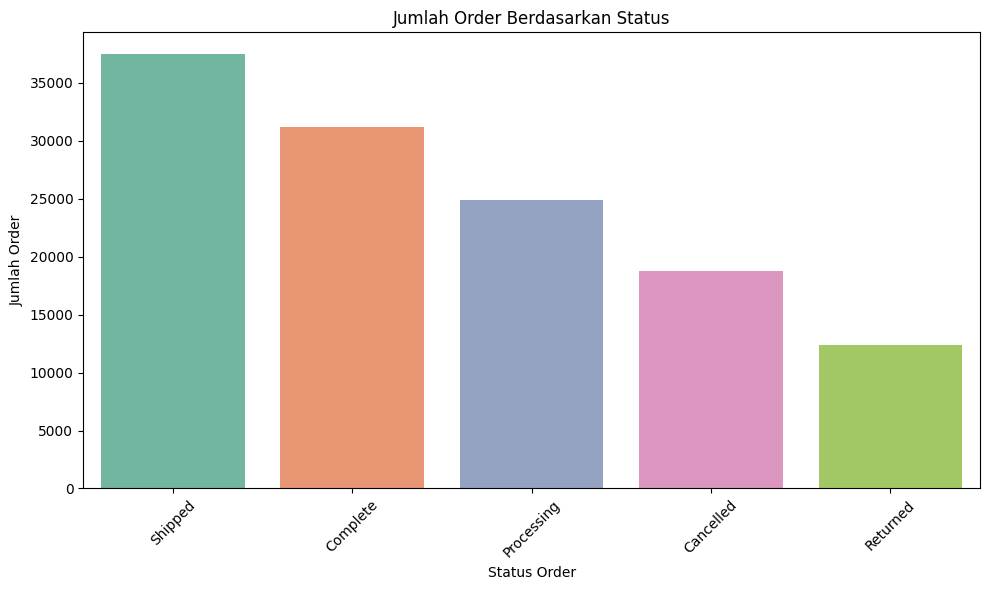

In [ ]:
# Visualisasi Tmbahan sesuai status

status_count = clean_orders["status"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=status_count.index,
    y=status_count.values,
    hue=status_count.index,
    palette="Set2",
    legend=False
)

plt.title("Jumlah Order Berdasarkan Status")
plt.xlabel("Status Order")
plt.ylabel("Jumlah Order")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
#Insights

df.groupby('status')['order_id'].count().sort_values(ascending=False)


,order_id
status,
Shipped,37493
Complete,31222
Processing,24903
Cancelled,18733
Returned,12424


In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'])

df.groupby(df['created_at'].dt.date)['order_id'].count()


,order_id
created_at,
2019-01-12,1
2019-01-22,1
2019-01-24,1
2019-01-27,1
2019-01-29,1
...,...
2026-08-24,547
2026-08-25,802
2026-08-26,1106


# OUTPUT & HANDOFF KE SESI 8

### Output Sesi 7
- Notebook Google Colab
- Dataset bersih `thelook_clean_session7.csv`
- Summary status
- Daily / monthly analysis
- Visualisasi dasar
- Minimal 2 insight

### Handoff
**Sesi 7: Cleaning + EDA**
↓
**Sesi 8: Analisis Python lanjutan**

Project tetap menggunakan dataset TheLook Ecommerce yang sama.
